In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu") #torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [2]:
# universal names for each column in the csv, added so that if the names are different we just have to change it here
# change the right values to what they are called in the csv file
CSV_COLUMNS = {
    "gene_name": "gene_name",
    "log2_fold_change": "log2FoldChange",
    "pvalue": "pvalue",
    "log_pvalue": "log_pvalue",
    "seq_length": "Sequence_Length",
    "first3": "First_3",
    "last3": "Last_3",
    "gc_pct": "GC_pct",
    "at_pct": "AT_pct",
}

In [3]:
# the purpose of this is that so the position of each base in the first/last 3 codons is taken into account
# this is better as it doesn't just take the 3 letter string as an input
BASES = ["A", "C", "G", "T"]

def one_hot_positions(series, prefix):
    """One-hot encode a column of 3-letter strings into 12 binary columns
    (3 positions x 4 bases)."""
    out = pd.DataFrame(index=series.index)
    for pos in range(3):
        for base in BASES:
            col_name = f"{prefix}_pos{pos+1}_{base}"
            out[col_name] = (series.str.upper().str[pos] == base).astype(int)
    return out

In [4]:
# pytorch dataset to handle data in correct format
class GeneDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# neural network model to predict numerical data
class GeneMLP(nn.Module):
    # input_dim = # of features in input matrix X
    # hidden1 = number of neurons hidden in the first layer
    #   - produces a number of outputs containing initial patterns
    # hidden2 = number of neurons hidden in the second layer
    #   - takes the outputs from the first layer and compresses it to smaller dimensions
    #   - helps distill the more important features
    # dropout = the % chance of a neuron "turning off" during training. this prevents:
    #   - the network becoming overly dependent on certain features (memorization)
    def __init__(self, input_dim, hidden1=32, hidden2=16, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    # pass input matrix X through neural network
    def forward(self, x):
        return self.net(x)

class TrainedModel:
    def __init__(self, fold_models, history, output, X_arr, y_arr):
        self.fold_models = fold_models
        self.history = history
        self.output_type = output
        self.X_arr = X_arr
        self.y_arr = y_arr

In [5]:
def train_one_fold_numeric(X_train, y_train, X_val, y_val, input_dim,
                           epochs=300, patience=20, lr=1e-3, weight_decay=1e-3,
                           batch_size=32, verbose=False):
    train_loader = DataLoader(GeneDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(GeneDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = GeneMLP(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
                
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:  # <--- Correctly iterating over the validation set
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(loss_fn(model(xb), yb).item())
        
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d} train={train_loss:.4f}  val={val_loss:.4f}")
        
        # early stopping
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            if verbose:
                print(f"  early stopping at epoch {epoch}")
            break
    
    model.load_state_dict(best_state)
    return model, history

In [6]:
def train_model_log2fc(input_file, data_pct):
    print(f"Training neural network on file {input_file} to predict log2 fold change")

    # our target is log2 fold change
    COLUMNS = CSV_COLUMNS.copy()
    COLUMNS["target"] = COLUMNS.pop("log2_fold_change")

    # extract data with pandas, not including gene name
    df_full = pd.read_csv(input_file).drop(columns=COLUMNS["gene_name"])
    print(f"\n Extracted data from {input_file}:")
    df_full.head()
    # train on half the rows by default
    if data_pct is None:
        data_pct = 0.5
    
    # randomize portion of data
    rng = np.random.default_rng(SEED)
    shuffled_idx = rng.permutation(len(df_full))
    num_training_rows = int(len(df_full) * data_pct)
    use_idx = shuffled_idx[:num_training_rows]
    unused_idx = shuffled_idx[num_training_rows:]

    df = df_full.iloc[use_idx].reset_index(drop=True)
    df_unused = df_full.iloc[unused_idx].reset_index(drop=True)
    print(f"Separated a random sample of {len(df)}/{len(df_full)} rows of data for training")

    
    # get first/last 3 one hot encodings
    first3_oh = one_hot_positions(df[COLUMNS["first3"]], "first3")
    last3_oh = one_hot_positions(df[COLUMNS["last3"]], "last3")

    numeric_cols = [COLUMNS["pvalue"], COLUMNS["log_pvalue"], COLUMNS["seq_length"], COLUMNS["gc_pct"], COLUMNS["at_pct"]]

    # join encodings with numeric columns
    X = pd.concat([df[numeric_cols].reset_index(drop=True), first3_oh.reset_index(drop=True), last3_oh.reset_index(drop=True)], axis=1)

    y = df[COLUMNS["target"]].values.astype(np.float32)

    print("Feature matrix shape:", X.shape)
    X.head()

    X_arr = X.values.astype(np.float32)
    y_arr = y

    # begin training model with 5 folds
    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_models = []

    print("\nTraining model...")
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        print(f"--- Fold {fold_idx + 1}/{N_FOLDS} ---")

        X_train_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_val = scaler.transform(X_val_raw)

        model, history = train_one_fold_numeric(
            X_train, y_train, X_val, y_val,
            input_dim=X_train.shape[1], verbose=True
        )

        model.eval()
        with torch.no_grad():
            val_preds = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()
        
        mae = mean_absolute_error(y_val, val_preds)
        rmse = mean_squared_error(y_val, val_preds) ** 0.5
        r2 = r2_score(y_val, val_preds)

        print(f"  Fold {fold_idx+1}  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
        fold_results.append({"fold": fold_idx + 1, "mae": mae, "rmse": rmse, "r2": r2})
        fold_models.append((model, scaler, val_idx))

    
    results_df = pd.DataFrame(fold_results)
    print("\n=== Cross-validation summary ===")
    print(results_df.to_string(index=False))
    print(f"\nMean MAE:  {results_df['mae'].mean():.4f}  +/- {results_df['mae'].std():.4f}")
    print(f"Mean RMSE: {results_df['rmse'].mean():.4f}  +/- {results_df['rmse'].std():.4f}")
    print(f"Mean R2:   {results_df['r2'].mean():.4f}  +/- {results_df['r2'].std():.4f}")


    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"],   label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("Training curve — last fold")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return TrainedModel(fold_models, history, "log2FoldChange", X_arr, y_arr)

In [7]:
def train_model_numeric(input_file, target_key, data_pct=None):
    print(f"Training neural network on file {input_file} to predict '{target_key}'")

    COLUMNS = CSV_COLUMNS.copy()
    
    # check if target exists in our dictionary
    if target_key not in COLUMNS:
        raise ValueError(f"Target '{target_key}' not found in CSV_COLUMNS dictionary.")
    
    target_col_name = COLUMNS[target_key]
    

    # extract data with pandas, not including gene name
    df_full = pd.read_csv(input_file).drop(columns=[COLUMNS["gene_name"]])
    print(f"\nExtracted data from {input_file}:")
    
    # train on half the rows by default
    if data_pct is None:
        data_pct = 0.5
    
    # randomize portion of data
    rng = np.random.default_rng(SEED)
    shuffled_idx = rng.permutation(len(df_full))
    num_training_rows = int(len(df_full) * data_pct)
    use_idx = shuffled_idx[:num_training_rows]
    unused_idx = shuffled_idx[num_training_rows:]

    df = df_full.iloc[use_idx].reset_index(drop=True)
    df_unused = df_full.iloc[unused_idx].reset_index(drop=True)
    print(f"Separated a random sample of {len(df)}/{len(df_full)} rows of data for training")

    # get first/last 3 one hot encodings
    first3_oh = one_hot_positions(df[COLUMNS["first3"]], "first3")
    last3_oh = one_hot_positions(df[COLUMNS["last3"]], "last3")


    # keys that should never be treated as standard numeric inputs
    # we remove pvalue and at_pct, because log pvalue and gc_pct are the same information, just represented differently
    exclude_keys = ["gene_name", "first3", "last3", "pvalue", "at_pct"]
    numeric_cols = []
    
    # validate input keys
    for key, col_name in COLUMNS.items():
        # skip text identifiers and one-hot encoded columns
        if key in exclude_keys:
            continue
            
        # skip the target variable so the model can't cheat
        if key == target_key:
            continue
            
            
        # if it passes all checks, it's a valid numeric feature
        numeric_cols.append(col_name)
        
    print(f"Using the following numeric features: {numeric_cols}")

    # join encodings with numeric columns
    X = pd.concat([df[numeric_cols].reset_index(drop=True), first3_oh.reset_index(drop=True), last3_oh.reset_index(drop=True)], axis=1)

    # dynamically set target variable
    y = df[target_col_name].values.astype(np.float32)

    print("Feature matrix shape:", X.shape)

    X_arr = X.values.astype(np.float32)
    y_arr = y

    # begin training model with 5 folds
    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_models = []

    print("\nTraining model...")
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        print(f"--- Fold {fold_idx + 1}/{N_FOLDS} ---")

        X_train_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_val = scaler.transform(X_val_raw)

        # Passes dynamic input_dim based on the number of features kept
        model, history = train_one_fold_numeric(
            X_train, y_train, X_val, y_val,
            input_dim=X_train.shape[1], verbose=True
        )

        model.eval()
        with torch.no_grad():
            val_preds = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()
        
        mae = mean_absolute_error(y_val, val_preds)
        rmse = mean_squared_error(y_val, val_preds) ** 0.5
        r2 = r2_score(y_val, val_preds)

        print(f"  Fold {fold_idx+1}  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
        fold_results.append({"fold": fold_idx + 1, "mae": mae, "rmse": rmse, "r2": r2})
        fold_models.append((model, scaler, val_idx))

    results_df = pd.DataFrame(fold_results)
    print("\n=== Cross-validation summary ===")
    print(results_df.to_string(index=False))
    print(f"\nMean MAE:  {results_df['mae'].mean():.4f}  +/- {results_df['mae'].std():.4f}")
    print(f"Mean RMSE: {results_df['rmse'].mean():.4f}  +/- {results_df['rmse'].std():.4f}")
    print(f"Mean R2:   {results_df['r2'].mean():.4f}  +/- {results_df['r2'].std():.4f}")

    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"],   label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("Training curve — last fold")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    
    return TrainedModel(fold_models, history, target_col_name, X_arr, y_arr)

In [8]:
# test and analyze model
def test_model(trained_model):
    all_true = []
    all_preds = []

    fold_models = trained_model.fold_models
    X_arr = trained_model.X_arr
    y_arr = trained_model.y_arr

    for model, scaler, val_idx in fold_models:
        X_val_raw = X_arr[val_idx]
        X_val_scaled = scaler.transform(X_val_raw)
        
        model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
            preds = model(X_tensor).cpu().numpy().flatten()
            
        all_true.extend(y_arr[val_idx])
        all_preds.extend(preds)

    all_true = np.array(all_true)
    all_preds = np.array(all_preds)
    
    # --- Calculate Residuals ---
    residuals = all_true - all_preds

    # Calculate Model Metrics
    overall_mae = mean_absolute_error(all_true, all_preds)
    overall_rmse = mean_squared_error(all_true, all_preds) ** 0.5
    overall_r2 = r2_score(all_true, all_preds)

    # --- Calculate Naive Baseline Metrics (Predicting the global mean) ---
    baseline_preds = np.full(all_true.shape, np.mean(y_arr))
    baseline_mae = mean_absolute_error(all_true, baseline_preds)
    baseline_r2 = r2_score(all_true, baseline_preds)

    print(f"=== Evaluation Dashboard ({trained_model.output_type}) ===")
    print(f"Model Metrics    -> Mean Absolute Error: {overall_mae:.4f} | Root Mean Squared Error: {overall_rmse:.4f} | R2: {overall_r2:.4f}")
    print(f"Baseline Metrics -> Mean Absolute Error: {baseline_mae:.4f} | R2: {baseline_r2:.4f}")
    if overall_r2 < baseline_r2:
        print("⚠️ ALERT: Your Neural Network is currently performing worse than predicting the mean.")
    else:
        print("✅ Neural Network performing better than predicting mean")
    print("=" * 45 + "\n")

    # --- Expanded 3-Plot Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Predicted vs Actual
    lims = [min(all_true.min(), all_preds.min()), max(all_true.max(), all_preds.max())]
    axes[0].scatter(all_true, all_preds, alpha=0.5, color="teal")
    axes[0].plot(lims, lims, "r--", label="Perfect Prediction")
    axes[0].set_xlabel(f"Actual {trained_model.output_type}")
    axes[0].set_ylabel(f"Predicted {trained_model.output_type}")
    axes[0].set_title("Predicted vs Actual")
    axes[0].legend()

    # Plot 2: Residuals vs Predicted (Look for systematic patterns)
    axes[1].scatter(all_preds, residuals, alpha=0.5, color="purple")
    axes[1].axhline(y=0, color="r", linestyle="--")
    axes[1].set_xlabel("Predicted Values")
    axes[1].set_ylabel("Residuals (Actual - Predicted)")
    axes[1].set_title("Residuals vs. Predicted")

    # Plot 3: Distribution of Errors (Should ideally be normal/bell-shaped)
    axes[2].hist(residuals, bins=20, color="dimgray", edgecolor="black", alpha=0.7)
    axes[2].axvline(x=0, color="r", linestyle="--")
    axes[2].set_xlabel("Prediction Error Magnitude")
    axes[2].set_ylabel("Count of Genes")
    axes[2].set_title("Distribution of Errors")

    plt.tight_layout()
    plt.show()
    
    return {"mae": overall_mae, "rmse": overall_rmse, "r2": overall_r2}

Training neural network on file PAO1.csv to predict 'log2_fold_change'

Extracted data from PAO1.csv:
Separated a random sample of 384/768 rows of data for training
Using the following numeric features: ['log_pvalue', 'Sequence_Length', 'GC_pct']
Feature matrix shape: (384, 27)

Training model...
--- Fold 1/5 ---
  epoch   0 train=0.8630  val=0.7177
  epoch  20 train=0.6260  val=0.6207
  early stopping at epoch 23
  Fold 1  MAE=0.6830  RMSE=0.7750  R2=0.1768
--- Fold 2/5 ---
  epoch   0 train=0.7472  val=1.1766
  epoch  20 train=0.5489  val=0.6686
  early stopping at epoch 26
  Fold 2  MAE=0.7160  RMSE=0.8166  R2=0.4282
--- Fold 3/5 ---
  epoch   0 train=0.7679  val=0.6250
  early stopping at epoch 4
  Fold 3  MAE=0.6952  RMSE=0.7841  R2=0.0451
--- Fold 4/5 ---
  epoch   0 train=0.9002  val=0.7089
  early stopping at epoch 18
  Fold 4  MAE=0.6630  RMSE=0.7234  R2=0.0586
--- Fold 5/5 ---
  epoch   0 train=0.9350  val=0.6984
  epoch  20 train=0.5991  val=0.5577
  early stopping at epoch 

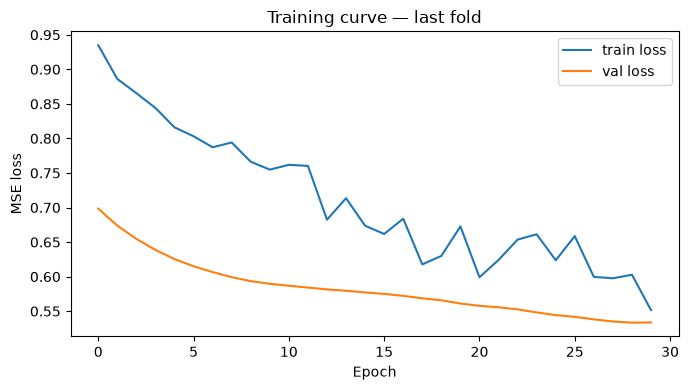

=== Evaluation Dashboard (log2FoldChange) ===
Model Metrics    -> Mean Absolute Error: 0.6836 | Root Mean Squared Error: 0.7677 | R2: 0.2078
Baseline Metrics -> Mean Absolute Error: 0.7287 | R2: 0.0000
✅ Neural Network performing better than predicting mean



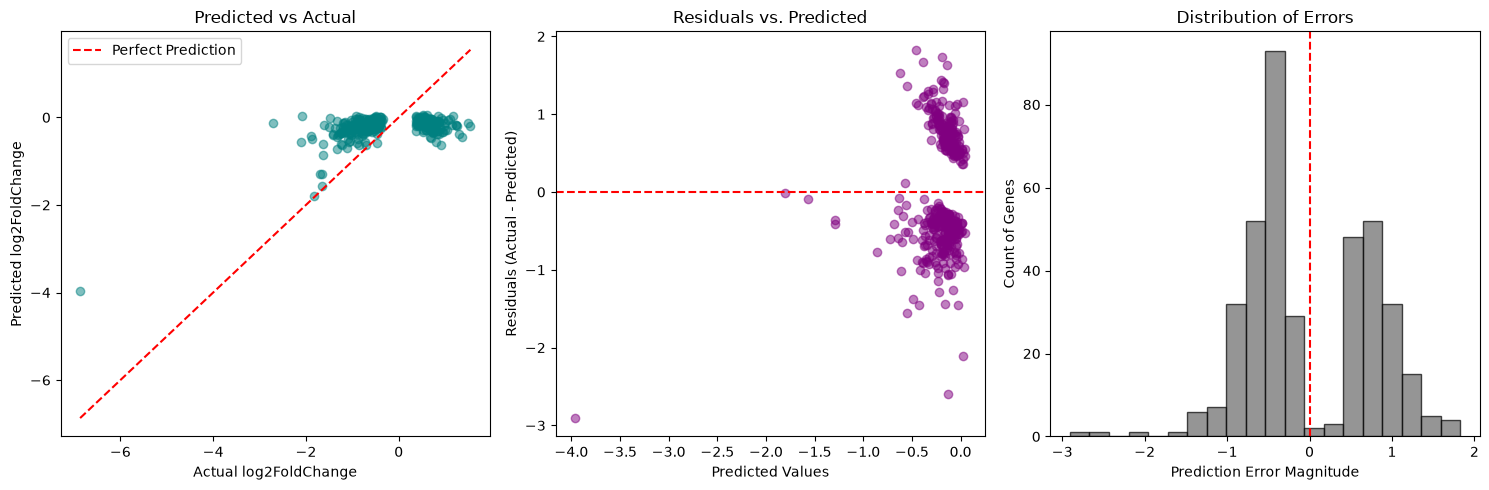

{'mae': 0.6835713386535645,
 'rmse': 0.7677249137161118,
 'r2': 0.20777267217636108}

In [9]:
# test log2 fold change
log2fc_model_50 = train_model_numeric("PAO1.csv", "log2_fold_change", .5)
test_model(log2fc_model_50)

Training neural network on file PAO1.csv to predict 'log_pvalue'

Extracted data from PAO1.csv:
Separated a random sample of 384/768 rows of data for training
Using the following numeric features: ['log2FoldChange', 'Sequence_Length', 'GC_pct']
Feature matrix shape: (384, 27)

Training model...
--- Fold 1/5 ---
  epoch   0 train=15.1802  val=13.2228
  epoch  20 train=6.0583  val=5.2015
  early stopping at epoch 33
  Fold 1  MAE=1.2398  RMSE=2.3922  R2=0.2006
--- Fold 2/5 ---
  epoch   0 train=11.7790  val=20.6586
  epoch  20 train=4.9138  val=9.0666
  early stopping at epoch 33
  Fold 2  MAE=1.2720  RMSE=3.0344  R2=0.4246
--- Fold 3/5 ---
  epoch   0 train=15.6927  val=13.1374
  epoch  20 train=6.8776  val=4.7744
  early stopping at epoch 37
  Fold 3  MAE=1.2392  RMSE=2.1937  R2=0.1897
--- Fold 4/5 ---
  epoch   0 train=17.4639  val=10.0483
  early stopping at epoch 17
  Fold 4  MAE=1.3463  RMSE=1.9077  R2=-0.0042
--- Fold 5/5 ---
  epoch   0 train=15.5445  val=9.8952
  epoch  20 train

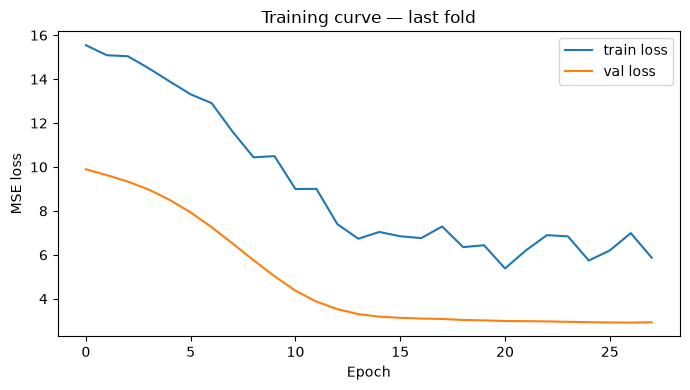

=== Evaluation Dashboard (log_pvalue) ===
Model Metrics    -> Mean Absolute Error: 1.2411 | Root Mean Squared Error: 2.3171 | R2: 0.2740
Baseline Metrics -> Mean Absolute Error: 1.4027 | R2: 0.0000
✅ Neural Network performing better than predicting mean



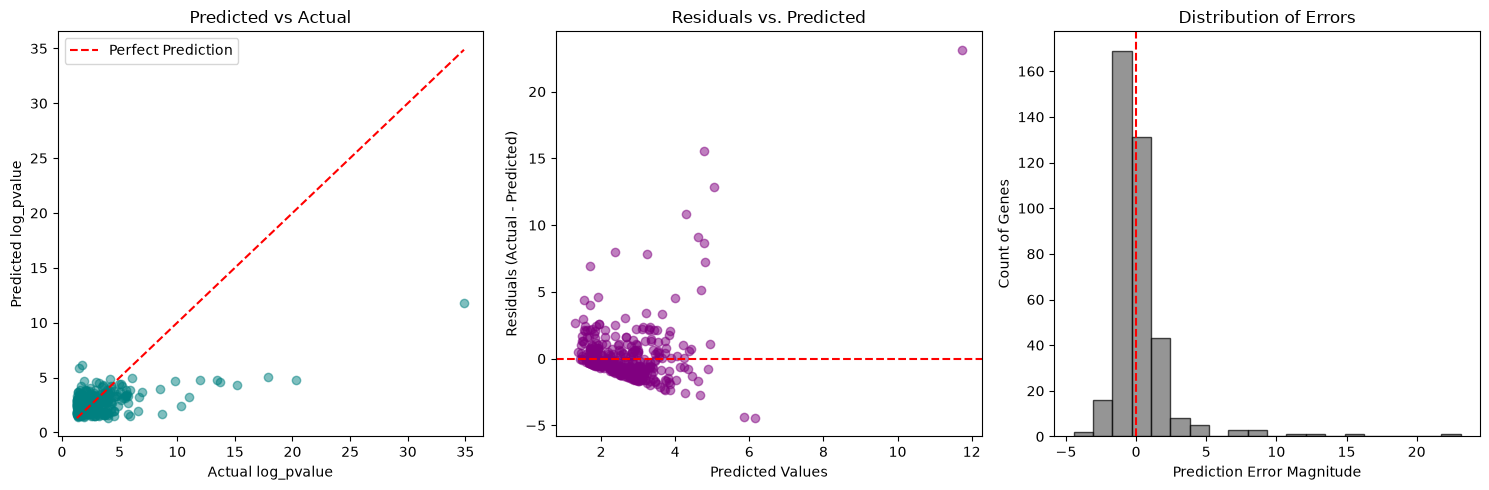

{'mae': 1.2411284446716309,
 'rmse': 2.3171429805375925,
 'r2': 0.27403563261032104}

In [12]:
# test pval
pvalue_model_50 = train_model_numeric("PAO1.csv", "log_pvalue", .5)
test_model(pvalue_model_50)

Training neural network on file PAO1.csv to predict 'gc_pct'

Extracted data from PAO1.csv:
Separated a random sample of 384/768 rows of data for training
Using the following numeric features: ['log2FoldChange', 'log_pvalue', 'Sequence_Length']
Feature matrix shape: (384, 27)

Training model...
--- Fold 1/5 ---
  epoch   0 train=4381.5487  val=4386.4639
  epoch  20 train=2043.2257  val=1824.2735
  epoch  40 train=331.3960  val=69.5852
  early stopping at epoch 43
  Fold 1  MAE=6.6774  RMSE=8.0313  R2=-3.0130
--- Fold 2/5 ---
  epoch   0 train=4340.8065  val=4342.7511
  epoch  20 train=1607.6912  val=1425.1560
  early stopping at epoch 39
  Fold 2  MAE=7.5746  RMSE=10.6234  R2=-8.1752
--- Fold 3/5 ---
  epoch   0 train=4343.3463  val=4288.9730
  epoch  20 train=1489.9265  val=1259.7590
  early stopping at epoch 36
  Fold 3  MAE=6.0673  RMSE=7.4804  R2=-1.5052
--- Fold 4/5 ---
  epoch   0 train=4380.7420  val=4397.2622
  epoch  20 train=2132.6374  val=2066.2521
  epoch  40 train=378.9538

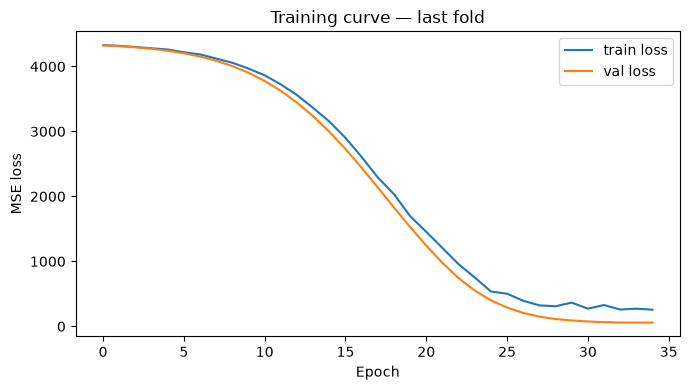

=== Evaluation Dashboard (GC_pct) ===
Model Metrics    -> Mean Absolute Error: 6.5650 | Root Mean Squared Error: 8.3728 | R2: -2.9283
Baseline Metrics -> Mean Absolute Error: 3.1121 | R2: 0.0000
⚠️ ALERT: Your Neural Network is currently performing worse than predicting the mean.



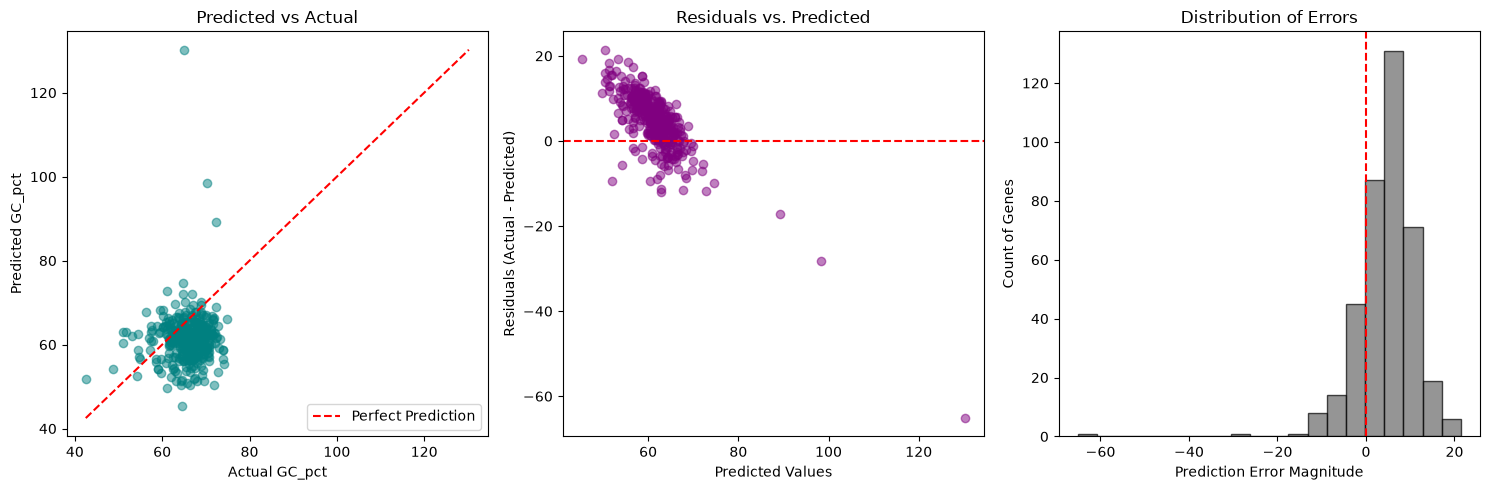

{'mae': 6.565008640289307,
 'rmse': 8.372845728500062,
 'r2': -2.9283108711242676}

In [11]:
gc_model_50 = train_model_numeric("PAO1.csv", "gc_pct", .5)
test_model(gc_model_50)